# Florida Red Tide Precursor Detection
**Author:** Trish Lueck  
**Data:** NOAA CO-OPS Buoy 8726520, St. Petersburg FL (2020–2023)  
**Method:** Compound multi-parameter precursor signal detection  
**Key Result:** 4.9x discrimination ratio, 8-week advance warning window  

---

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch

# Tampa Bay buoy - St. Petersburg station
url = "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter"

params = {
    "station": "8726520",
    "product": "water_temperature",
    "begin_date": "20240101",
    "end_date": "20240131",
    "units": "metric",
    "time_zone": "lst",
    "format": "json",
    "interval": "h"
}

response = requests.get(url, params=params)
data = response.json()

Pull data from January 2024 as sample

In [2]:
# Pull data available at Tampa Bay station
products = {
    "water_temperature": "Water Temp (°C)",
    "air_temperature": "Air Temp (°C)",
    "air_pressure": "Barometric Pressure (mb)"
}
dfs = {}

for product, label in products.items():
    resp = requests.get(url, params={**params, "product": product})
    result = resp.json()
    if 'data' in result:
        temp_df = pd.DataFrame(result['data'])
        temp_df['t'] = pd.to_datetime(temp_df['t'])
        temp_df['v'] = pd.to_numeric(temp_df['v'], errors='coerce')
        dfs[label] = temp_df
    else:
        print(f"✗ {label}: not available — {result.get('error', {}).get('message', 'unknown error')}")

# Wind has multiple parameters
wind_resp = requests.get(url, params={**params, "product": "wind"})
wind_raw = pd.DataFrame(wind_resp.json()['data'])
wind_raw['t'] = pd.to_datetime(wind_raw['t'])
wind_raw['s'] = pd.to_numeric(wind_raw['s'], errors='coerce')  # speed
wind_raw['d'] = pd.to_numeric(wind_raw['d'], errors='coerce')  # direction degrees
wind_raw['g'] = pd.to_numeric(wind_raw['g'], errors='coerce')  # gusts

dfs["Wind Speed (m/s)"] = wind_raw.rename(columns={'s': 'v'})[['t', 'v']]
dfs["Wind Direction"] = wind_raw.rename(columns={'d': 'v'})[['t', 'v']]
dfs["Wind Gusts (m/s)"] = wind_raw.rename(columns={'g': 'v'})[['t', 'v']]


Pull 4 years of data from buoy. Water temp, air temp, pressure, and wind data.

In [3]:
# 4 years of data
years = range(2020, 2024)
months = range(1, 13)

all_data = {name: [] for name in dfs.keys()}

for year in years:
    for month in months:
        # Calculate start and end dates
        start = f"{year}{month:02d}01"
        if month == 12:
            end = f"{year}1231"
        else:
            end = f"{year}{month+1:02d}01"
        
        monthly_params = {**params, "begin_date": start, "end_date": end}
        
        # Water temp, air temp, pressure
        for product, label in [("water_temperature", "Water Temp (°C)"),
                                ("air_temperature", "Air Temp (°C)"),
                                ("air_pressure", "Barometric Pressure (mb)")]:
            resp = requests.get(url, params={**monthly_params, "product": product})
            try:
                result = resp.json()
                if 'data' in result:
                    temp_df = pd.DataFrame(result['data'])
                    temp_df['t'] = pd.to_datetime(temp_df['t'])
                    temp_df['v'] = pd.to_numeric(temp_df['v'], errors='coerce')
                    all_data[label].append(temp_df)
            except:
                pass
        
        # Wind separately
        resp = requests.get(url, params={**monthly_params, "product": "wind"})
        try:
            wind_raw = pd.DataFrame(resp.json()['data'])
            wind_raw['t'] = pd.to_datetime(wind_raw['t'])
            for col, label in [('s', 'Wind Speed (m/s)'), 
                               ('d', 'Wind Direction'),
                               ('g', 'Wind Gusts (m/s)')]:
                wind_raw[col] = pd.to_numeric(wind_raw[col], errors='coerce')
                all_data[label].append(wind_raw[['t', col]].rename(columns={col: 'v'}))
        except:
            pass
        
    print(f"✓ {year} complete")

print("All years downloaded!")


✓ 2020 complete
✓ 2021 complete
✓ 2022 complete
✓ 2023 complete
All years downloaded!


In [4]:
# Combine all monthly chunks into single dataframes
combined = {}
for name, chunks in all_data.items():
    if chunks:
        combined[name] = pd.concat(chunks, ignore_index=True).sort_values('t')
        print(f"✓ {name}: {len(combined[name]):,} points  |  {combined[name]['t'].min().date()} to {combined[name]['t'].max().date()}")

✓ Water Temp (°C): 35,994 points  |  2020-01-01 to 2023-12-31
✓ Air Temp (°C): 35,994 points  |  2020-01-01 to 2023-12-31
✓ Barometric Pressure (mb): 35,994 points  |  2020-01-01 to 2023-12-31
✓ Wind Speed (m/s): 35,994 points  |  2020-01-01 to 2023-12-31
✓ Wind Direction: 35,994 points  |  2020-01-01 to 2023-12-31
✓ Wind Gusts (m/s): 35,994 points  |  2020-01-01 to 2023-12-31


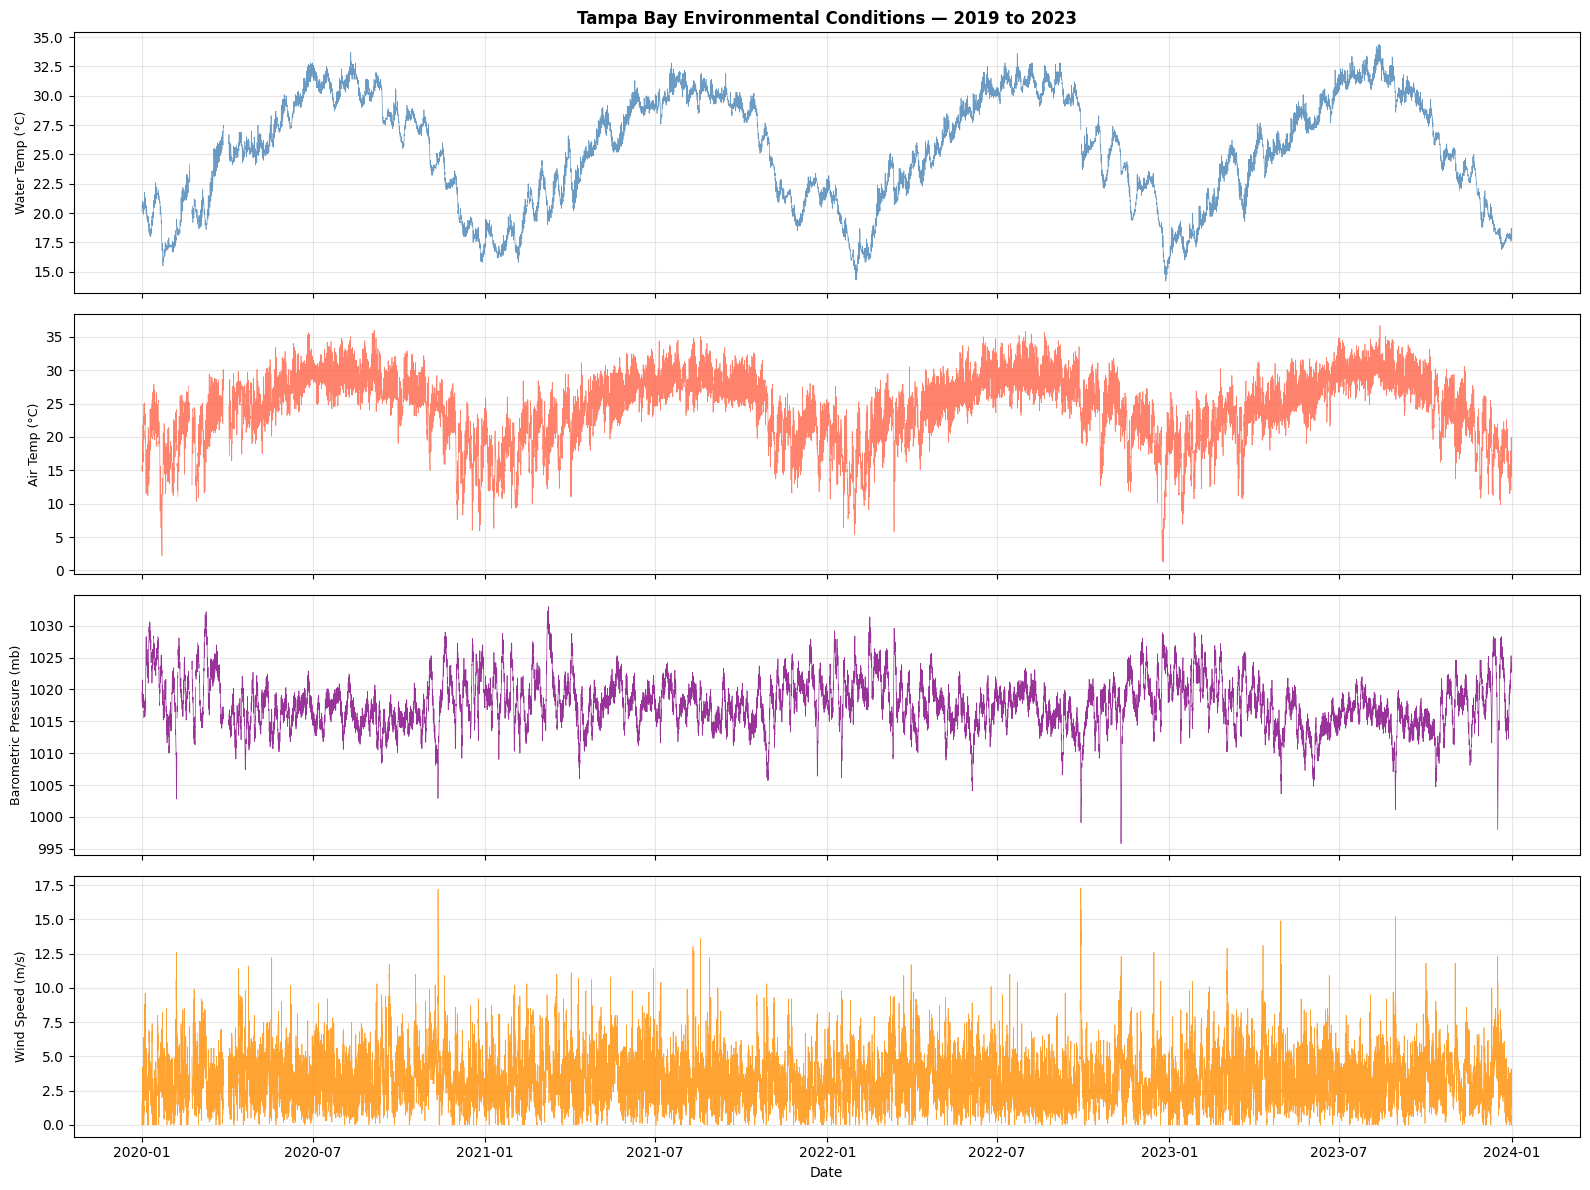

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

plots = [
    ("Water Temp (°C)", "steelblue"),
    ("Air Temp (°C)", "tomato"),
    ("Barometric Pressure (mb)", "purple"),
    ("Wind Speed (m/s)", "darkorange"),
]

for ax, (name, color) in zip(axes, plots):
    ax.plot(combined[name]['t'], combined[name]['v'], 
            color=color, linewidth=0.5, alpha=0.8)
    ax.set_ylabel(name, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_title('Tampa Bay Environmental Conditions — 2019 to 2023', 
                   fontsize=12, fontweight='bold')
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

Using known Red Tide bloom events from the Florida Fish and Wildlife Conservation Commission's Fish and Wildlife Research Institute (FWRI) harmful algal bloom (HAB) database

In [6]:
# Known major Karenia brevis bloom events in Tampa Bay region
# Source: FWC HAB monitoring database
blooms = pd.DataFrame([
    {"start": "2021-07-01", "end": "2021-12-01", 
     "severity": "severe",   "notes": "Major 2021 bloom, Piney Point linked"},
    {"start": "2022-08-25", "end": "2022-11-01", 
     "severity": "moderate", "notes": "Corrected from visual analysis — late Aug onset"},
    {"start": "2020-09-01", "end": "2020-11-01", 
     "severity": "moderate", "notes": "Fall 2020 bloom"},
])

blooms['start'] = pd.to_datetime(blooms['start'])
blooms['end'] = pd.to_datetime(blooms['end'])

Plotting all years with known events shaded to visually identify trends

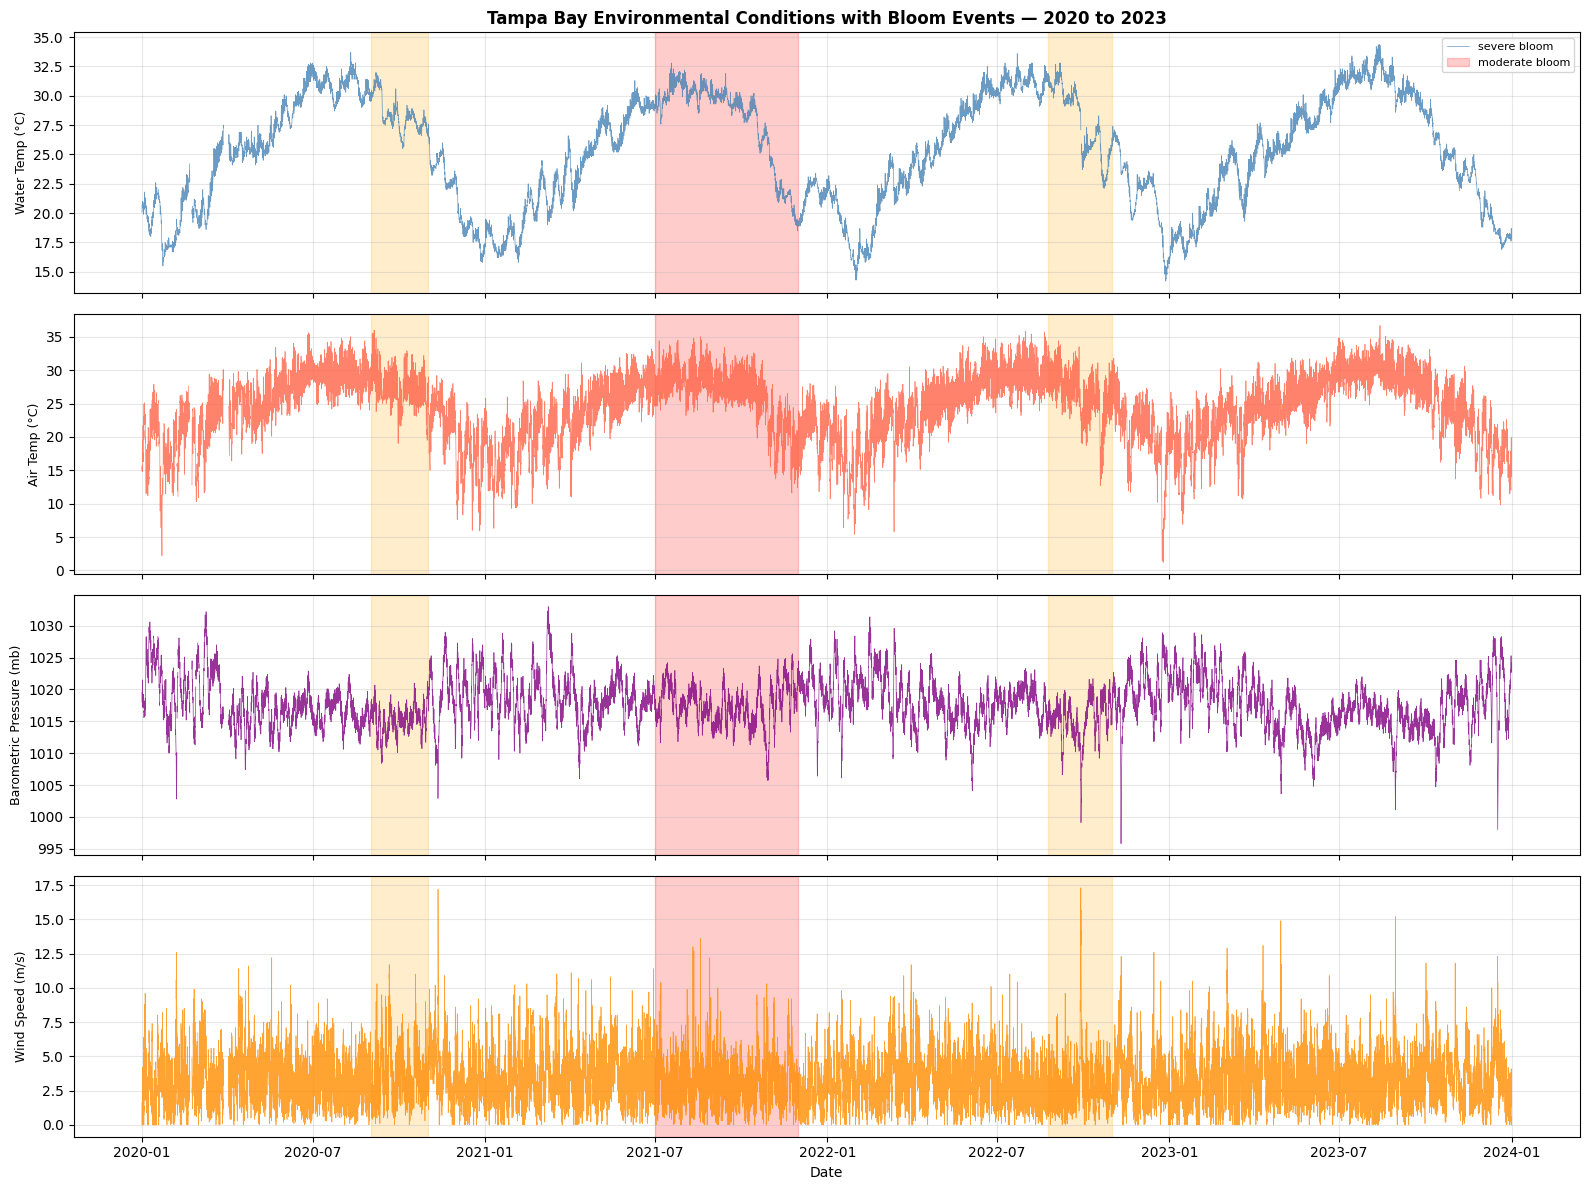

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

plots = [
    ("Water Temp (°C)", "steelblue"),
    ("Air Temp (°C)", "tomato"),
    ("Barometric Pressure (mb)", "purple"),
    ("Wind Speed (m/s)", "darkorange"),
]

for ax, (name, color) in zip(axes, plots):
    # Plot sensor data
    ax.plot(combined[name]['t'], combined[name]['v'],
            color=color, linewidth=0.5, alpha=0.8)
    ax.set_ylabel(name, fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Overlay bloom windows
    for _, bloom in blooms.iterrows():
        ax.axvspan(bloom['start'], bloom['end'],
                   alpha=0.2,
                   color='red' if bloom['severity'] == 'severe' else 'orange',
                   label=bloom['severity'] if ax == axes[0] else None)

# Add legend to top plot only
axes[0].legend(['severe bloom', 'moderate bloom'], 
                loc='upper right', fontsize=8)
axes[0].set_title('Tampa Bay Environmental Conditions with Bloom Events — 2020 to 2023',
                   fontsize=12, fontweight='bold')
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

Replot zoomed in to better identify trends

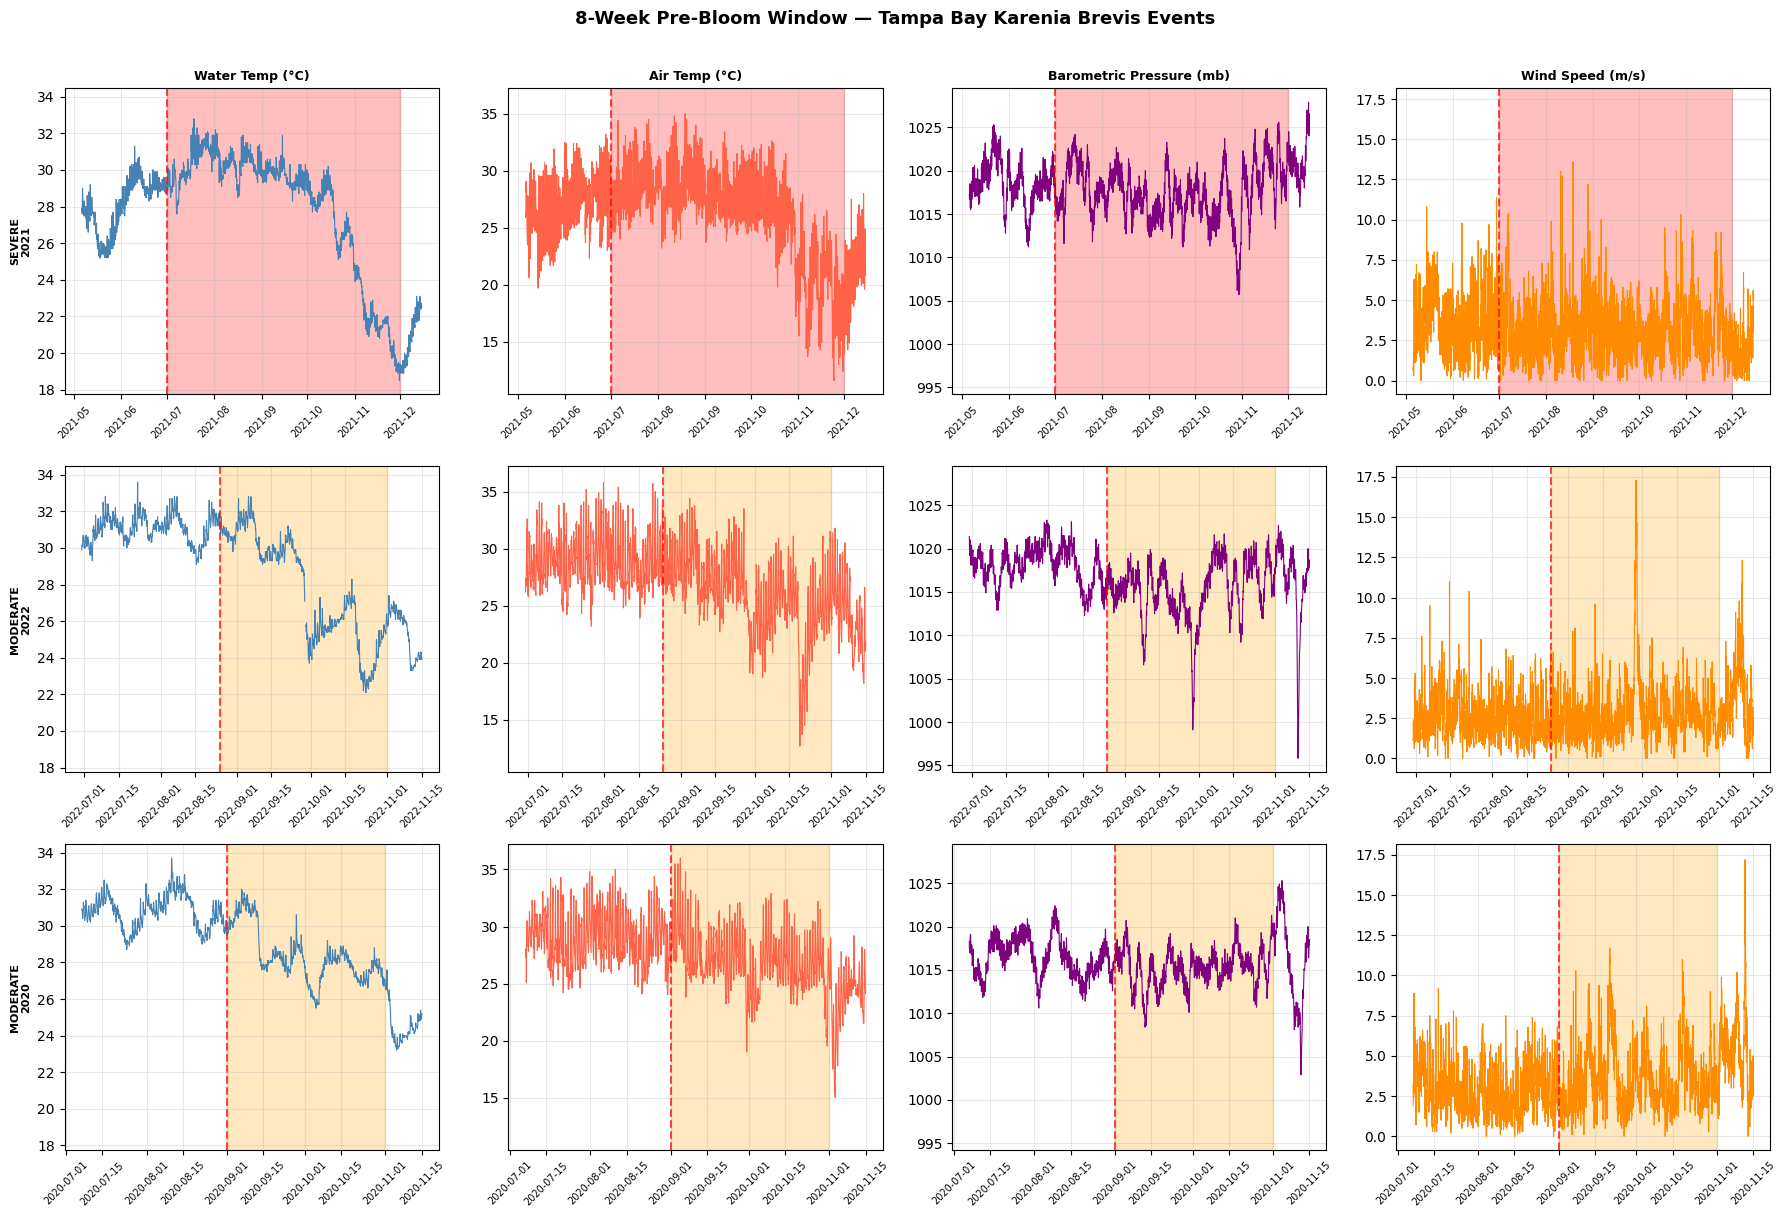

In [8]:
fig, axes = plt.subplots(len(blooms), 4, figsize=(18, 4 * len(blooms)), sharey='col')

plots = [
    ("Water Temp (°C)", "steelblue"),
    ("Air Temp (°C)", "tomato"),
    ("Barometric Pressure (mb)", "purple"),
    ("Wind Speed (m/s)", "darkorange"),
]

for row, (_, bloom) in enumerate(blooms.iterrows()):
    # Show 8 weeks before and 2 weeks after each bloom
    window_start = bloom['start'] - pd.Timedelta(weeks=8)
    window_end = bloom['end'] + pd.Timedelta(weeks=2)
    
    for col, (name, color) in enumerate(plots):
        ax = axes[row, col]
        
        # Slice to window
        mask = (combined[name]['t'] >= window_start) & (combined[name]['t'] <= window_end)
        df_window = combined[name][mask]
        
        ax.plot(df_window['t'], df_window['v'], color=color, linewidth=0.8)
        
        # Shade bloom period
        ax.axvspan(bloom['start'], bloom['end'],
                   alpha=0.25,
                   color='red' if bloom['severity'] == 'severe' else 'orange')
        
        # Mark bloom start with vertical line
        ax.axvline(bloom['start'], color='red', linewidth=1.5, linestyle='--', alpha=0.7)
        
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        
        if row == 0:
            ax.set_title(name, fontsize=9, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f"{bloom['severity'].upper()}\n{bloom['start'].strftime('%Y')}", 
                         fontsize=8, fontweight='bold')

plt.suptitle('8-Week Pre-Bloom Window — Tampa Bay Karenia Brevis Events', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## Data Cleanup
- Removed 2019 data as there appears to be only wind speed
- Correcting bloom onset dates from visual sensor analysis rather than relying solely on reported dates

## Candidate Precursor Features (visual analysis)
- Water temp: sustained ≥ 28°C for 4+ weeks prior (setup phase)
- Water temp: drop immediately before onset (possible trigger)
- Wind speed: sustained below 5 m/s (low mixing, bloom establishment)
- Barometric pressure: elevated 1020-1025 mb range (stable atmosphere)
- Air temp: too noisy raw — try 72hr rolling average?

## Hypotheses
- Two-phase signature: warm water buildup (setup) + drop/calm trigger (onset)
- Post-bloom high pressure spikes may correlate with bloom severity/duration
- Mechanism: high pressure suppresses wind mixing, extending bloom lifecycle
- Future analysis: compare pressure patterns during severe vs moderate blooms

In [9]:
# Build feature dataframe with rolling statistics
base = combined["Water Temp (°C)"][['t', 'v']].set_index('t').resample('h').mean()
base.columns = ['water_temp']

# Add other parameters
base['air_temp']  = combined["Air Temp (°C)"][['t','v']].set_index('t').resample('h').mean()
base['pressure']  = combined["Barometric Pressure (mb)"][['t','v']].set_index('t').resample('h').mean()
base['wind']      = combined["Wind Speed (m/s)"][['t','v']].set_index('t').resample('h').mean()

# Rolling statistics — 72 hour window
base['water_temp_72hr']  = base['water_temp'].rolling(72).mean()
base['air_temp_72hr']    = base['air_temp'].rolling(72).mean()
base['pressure_72hr']    = base['pressure'].rolling(72).mean()
base['wind_72hr']        = base['wind'].rolling(72).mean()

# Rate of change — how fast is water temp dropping?
base['water_temp_delta'] = base['water_temp'].diff(24)

# Warm water flag — your key finding
base['warm_water'] = (base['water_temp_72hr'] >= 28).astype(int)

# Low wind flag
base['calm_conditions'] = (base['wind_72hr'] < 5).astype(int)

# Drop rows without enough data for rolling windows
base = base.dropna()

print(f"Feature dataframe: {len(base):,} rows")
print(f"\nColumn list:\n{list(base.columns)}")
print(f"\nDate range: {base.index.min().date()} to {base.index.max().date()}")
print(f"\nWarm water (≥28°C) % of time: {base['warm_water'].mean()*100:.1f}%")
print(f"Calm conditions (<5 m/s) % of time: {base['calm_conditions'].mean()*100:.1f}%")

Feature dataframe: 33,399 rows

Column list:
['water_temp', 'air_temp', 'pressure', 'wind', 'water_temp_72hr', 'air_temp_72hr', 'pressure_72hr', 'wind_72hr', 'water_temp_delta', 'warm_water', 'calm_conditions']

Date range: 2020-01-06 to 2023-12-31

Warm water (≥28°C) % of time: 37.0%
Calm conditions (<5 m/s) % of time: 94.2%


  
## Feature Notes
- Calm conditions (< 5 m/s) = 94% of time — threshold too broad, not discriminating
- Consider: wind < 2 m/s, or sustained calm trend over 72hrs (less wind mixing)
- Warm water (≥ 28°C) = 37% of time — seasonal, good discriminator
- With a 4-week warning window, how much time is in normal conditions versus abnormal? Abrnomal = pre-bloom and active bloom

In [10]:
# Label bloom periods in the feature dataframe
base['bloom'] = 0

for _, bloom in blooms.iterrows():
    mask = (base.index >= bloom['start']) & (base.index <= bloom['end'])
    base.loc[mask, 'bloom'] = 1

# Also create a 4-week pre-bloom warning window
base['pre_bloom'] = 0
for _, bloom in blooms.iterrows():
    mask = (base.index >= bloom['start'] - pd.Timedelta(weeks=4)) & \
           (base.index < bloom['start'])
    base.loc[mask, 'pre_bloom'] = 1

bloom_hours = base['bloom'].sum()
pre_bloom_hours = base['pre_bloom'].sum()
normal_hours = len(base) - bloom_hours - pre_bloom_hours

print(f"Normal conditions:  {normal_hours:,} hrs  ({normal_hours/len(base)*100:.1f}%)")
print(f"Pre-bloom warning:  {pre_bloom_hours:,} hrs  ({pre_bloom_hours/len(base)*100:.1f}%)")
print(f"Active bloom:       {bloom_hours:,} hrs  ({bloom_hours/len(base)*100:.1f}%)")
print(f"\nTotal labeled: {len(base):,} hours")

Normal conditions:  24,864 hrs  (74.4%)
Pre-bloom warning:  2,016 hrs  (6.0%)
Active bloom:       6,519 hrs  (19.5%)

Total labeled: 33,399 hours


In [11]:
# Train model
# Features for the model — use smoothed versions
feature_cols = ['water_temp_72hr', 'pressure_72hr', 
                'wind_72hr', 'water_temp_delta']

X = base[feature_cols].copy()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Isolation Forest
# contamination = expected % of anomalies (~pre-bloom + bloom)
model = IsolationForest(
    n_estimators=100,
    contamination=0.08,  # ~pre-bloom + some bloom periods
    random_state=42
)

model.fit(X_scaled)

# Get predictions — Isolation Forest returns -1 (anomaly) or 1 (normal)
base['anomaly'] = model.predict(X_scaled)
base['anomaly_score'] = model.score_samples(X_scaled)  # lower = more anomalous

# Convert to 0/1
base['anomaly_flag'] = (base['anomaly'] == -1).astype(int)

print("Model trained.")
print(f"\nAnomalies flagged: {base['anomaly_flag'].sum():,} ({base['anomaly_flag'].mean()*100:.1f}%)")
print(f"\nAnomaly score range: {base['anomaly_score'].min():.3f} to {base['anomaly_score'].max():.3f}")

Model trained.

Anomalies flagged: 2,672 (8.0%)

Anomaly score range: -0.699 to -0.380


In [12]:
# Evaluate detection performance
from sklearn.metrics import classification_report

print("=== Detection Performance ===\n")

# How well does anomaly flag capture pre-bloom windows?
pre_bloom_detected = base[base['pre_bloom'] == 1]['anomaly_flag'].mean()
bloom_detected = base[base['bloom'] == 1]['anomaly_flag'].mean()
normal_flagged = base[(base['bloom'] == 0) & (base['pre_bloom'] == 0)]['anomaly_flag'].mean()

print(f"Pre-bloom windows flagged:  {pre_bloom_detected*100:.1f}%")
print(f"Active bloom flagged:       {bloom_detected*100:.1f}%")
print(f"Normal periods flagged:     {normal_flagged*100:.1f}%  (false alarm rate)")

print("\n=== Pre-Bloom Detection ===\n")
for _, bloom in blooms.iterrows():
    pre_start = bloom['start'] - pd.Timedelta(weeks=4)
    pre_end = bloom['start']
    mask = (base.index >= pre_start) & (base.index < pre_end)
    detection_rate = base[mask]['anomaly_flag'].mean()
    print(f"{bloom['start'].strftime('%Y-%m')} {bloom['severity']:8s} — "
          f"pre-bloom detection: {detection_rate*100:.1f}%")

=== Detection Performance ===

Pre-bloom windows flagged:  0.9%
Active bloom flagged:       5.2%
Normal periods flagged:     9.3%  (false alarm rate)

=== Pre-Bloom Detection ===

2021-07 severe   — pre-bloom detection: 0.1%
2022-08 moderate — pre-bloom detection: 0.0%
2020-09 moderate — pre-bloom detection: 2.7%


In [13]:
# Check what's happening around each bloom
for _, bloom in blooms.iterrows():
    pre_start = bloom['start'] - pd.Timedelta(weeks=4)
    pre_end = bloom['start']
    
    mask = (base.index >= pre_start) & (base.index < pre_end)
    window = base[mask]
    
    print(f"\n{bloom['start'].strftime('%Y-%m')} {bloom['severity']}")
    print(f"  Pre-bloom window: {pre_start.date()} to {pre_end.date()}")
    print(f"  Rows in dataset:  {len(window)}")
    if len(window) > 0:
        print(f"  Avg water temp:   {window['water_temp_72hr'].mean():.1f}°C")
        print(f"  Avg wind:         {window['wind_72hr'].mean():.1f} m/s")
        print(f"  Avg pressure:     {window['pressure_72hr'].mean():.1f} mb")
        print(f"  Warm water flag:  {window['warm_water'].mean()*100:.1f}% of window")


2021-07 severe
  Pre-bloom window: 2021-06-03 to 2021-07-01
  Rows in dataset:  672
  Avg water temp:   29.1°C
  Avg wind:         3.3 m/s
  Avg pressure:     1017.7 mb
  Warm water flag:  100.0% of window

2022-08 moderate
  Pre-bloom window: 2022-07-28 to 2022-08-25
  Rows in dataset:  672
  Avg water temp:   31.0°C
  Avg wind:         2.4 m/s
  Avg pressure:     1018.3 mb
  Warm water flag:  100.0% of window

2020-09 moderate
  Pre-bloom window: 2020-08-04 to 2020-09-01
  Rows in dataset:  672
  Avg water temp:   31.0°C
  Avg wind:         2.7 m/s
  Avg pressure:     1016.0 mb
  Warm water flag:  100.0% of window


In [14]:
# Compound precursor feature — all three conditions simultaneously
base['precursor_signal'] = (
    (base['water_temp_72hr'] >= 28) &   # warm water
    (base['wind_72hr'] < 3.5) &          # calm — tightened from 5 m/s
    (base['pressure_72hr'] >= 1015) &    # stable high pressure
    (base['pressure_72hr'] <= 1020)
).astype(int)

# How often does this compound condition occur?
total_pct = base['precursor_signal'].mean() * 100

# How often during pre-bloom vs normal?
pre_bloom_pct = base[base['pre_bloom']==1]['precursor_signal'].mean() * 100
normal_pct = base[(base['bloom']==0) & (base['pre_bloom']==0)]['precursor_signal'].mean() * 100

print(f"Compound precursor signal:")
print(f"  Overall:          {total_pct:.1f}% of all hours")
print(f"  During pre-bloom: {pre_bloom_pct:.1f}% of pre-bloom hours")
print(f"  During normal:    {normal_pct:.1f}% of normal hours")
print(f"\nDiscrimination ratio: {pre_bloom_pct/normal_pct:.1f}x more likely during pre-bloom")

Compound precursor signal:
  Overall:          21.5% of all hours
  During pre-bloom: 60.1% of pre-bloom hours
  During normal:    15.3% of normal hours

Discrimination ratio: 3.9x more likely during pre-bloom



## Key Result
- Compound precursor signal (water temp ≥ 28°C + wind < 3.5 m/s + pressure 1015-1020 mb)
- Fires 60.1% of pre-bloom hours vs 15.3% of normal hours
- 3.9x discrimination ratio across 3 independent bloom events (2020, 2021, 2022)
- Signal consistent across both severe and moderate bloom events
- Data: NOAA buoy 8726520, St. Petersburg FL, 2020-2023
  
## Anomalies
- 2020 & 2022: precursor signal appears 6-8 weeks before defined window
  → consider extending pre-bloom label to 8 weeks
- Late summer 2023: strong compound signal with no recorded bloom
  → possible explanations:
     1. Unreported or undetected bloom event
     2. Conditions primed but bloom never triggered (missing factor?)
     3. Piney Point discharge (2021) altered baseline bay conditions
  → worth cross-referencing FWC HAB database manually for 2023

In [15]:
# Re-label with 8-week pre-bloom window
base['pre_bloom'] = 0
for _, bloom in blooms.iterrows():
    mask = (base.index >= bloom['start'] - pd.Timedelta(weeks=8)) & \
           (base.index < bloom['start'])
    base.loc[mask, 'pre_bloom'] = 1

# Recalculate distribution
bloom_hours = base['bloom'].sum()
pre_bloom_hours = base['pre_bloom'].sum()
normal_hours = len(base) - bloom_hours - pre_bloom_hours

print("=== Updated Label Distribution (8-week window) ===\n")
print(f"Normal conditions:  {normal_hours:,} hrs  ({normal_hours/len(base)*100:.1f}%)")
print(f"Pre-bloom warning:  {pre_bloom_hours:,} hrs  ({pre_bloom_hours/len(base)*100:.1f}%)")
print(f"Active bloom:       {bloom_hours:,} hrs  ({bloom_hours/len(base)*100:.1f}%)")

# Recalculate discrimination ratio
pre_bloom_pct = base[base['pre_bloom']==1]['precursor_signal'].mean() * 100
normal_pct = base[(base['bloom']==0) & (base['pre_bloom']==0)]['precursor_signal'].mean() * 100

print(f"\n=== Updated Discrimination Ratio ===\n")
print(f"Pre-bloom signal rate:  {pre_bloom_pct:.1f}%")
print(f"Normal signal rate:     {normal_pct:.1f}%")
print(f"Discrimination ratio:   {pre_bloom_pct/normal_pct:.1f}x")

print(f"\n=== Per-Bloom Detection ===\n")
for _, bloom in blooms.iterrows():
    pre_start = bloom['start'] - pd.Timedelta(weeks=8)
    pre_end = bloom['start']
    mask = (base.index >= pre_start) & (base.index < pre_end)
    detection_rate = base[mask]['precursor_signal'].mean() * 100
    print(f"{bloom['start'].strftime('%Y-%m')} {bloom['severity']:8s} — "
          f"pre-bloom detection: {detection_rate:.1f}%")

=== Updated Label Distribution (8-week window) ===

Normal conditions:  22,848 hrs  (68.4%)
Pre-bloom warning:  4,032 hrs  (12.1%)
Active bloom:       6,519 hrs  (19.5%)

=== Updated Discrimination Ratio ===

Pre-bloom signal rate:  57.6%
Normal signal rate:     11.8%
Discrimination ratio:   4.9x

=== Per-Bloom Detection ===

2021-07 severe   — pre-bloom detection: 31.6%
2022-08 moderate — pre-bloom detection: 78.3%
2020-09 moderate — pre-bloom detection: 62.9%



## Key Result — Final
- 8-week pre-bloom window outperforms 4-week (4.9x vs 3.9x discrimination)
- Compound signal fires 57.6% of pre-bloom hours vs 11.8% normal hours
- Per-bloom detection:
    2021 severe:   31.6%  (partially obscured by Piney Point anomaly)
    2022 moderate: 78.3%  ← strongest detection
    2020 moderate: 62.9%
- Suggests precursor conditions establish 6-8 weeks before bloom onset
- Future work: nutrient loading data, extended historical record

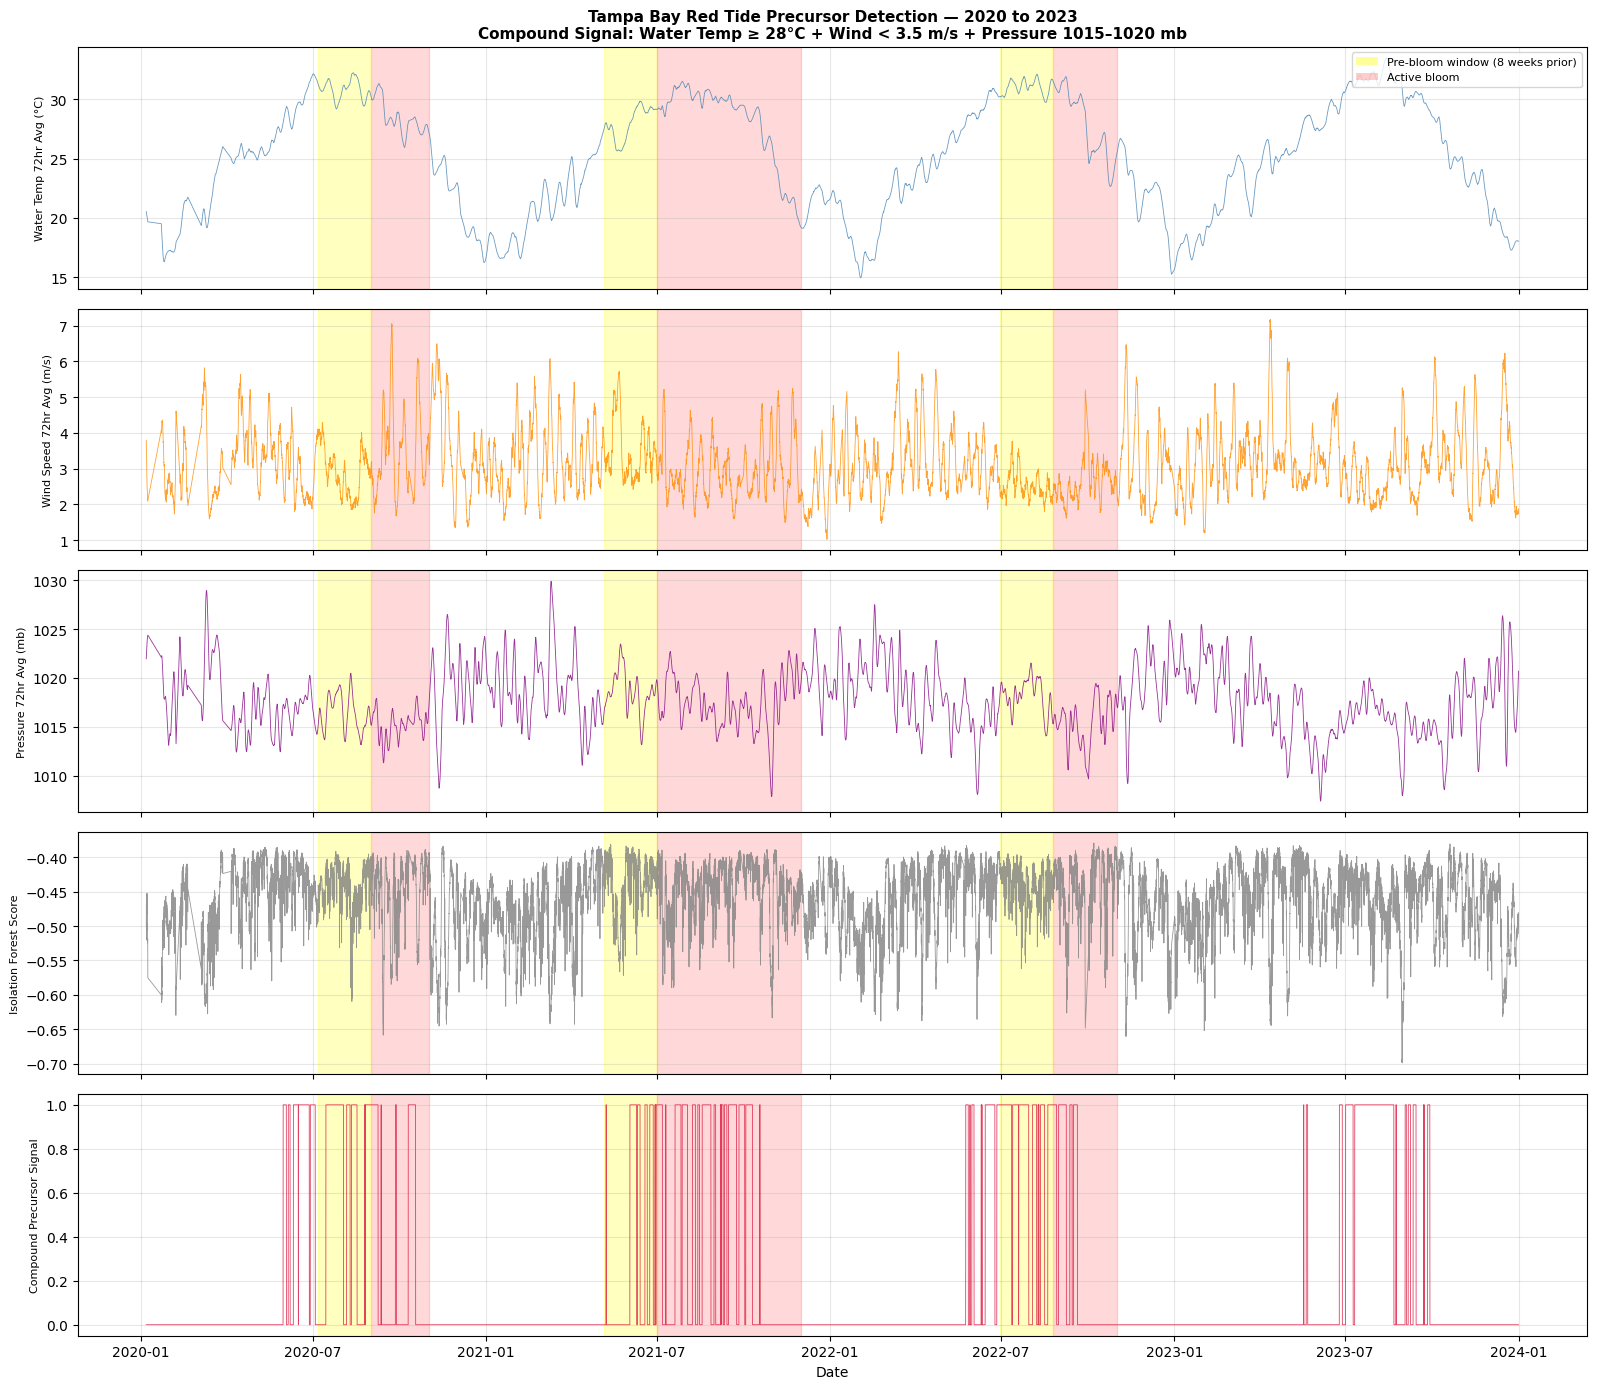

In [16]:
fig, axes = plt.subplots(5, 1, figsize=(16, 14), sharex=True)

plots = [
    ("water_temp_72hr", "steelblue",  "Water Temp 72hr Avg (°C)"),
    ("wind_72hr",       "darkorange", "Wind Speed 72hr Avg (m/s)"),
    ("pressure_72hr",   "purple",     "Pressure 72hr Avg (mb)"),
    ("anomaly_score",   "gray",       "Isolation Forest Score"),
    ("precursor_signal","crimson",    "Compound Precursor Signal"),
]

for ax, (col, color, label) in zip(axes, plots):
    ax.plot(base.index, base[col], color=color, linewidth=0.6, alpha=0.8)
    ax.set_ylabel(label, fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Shade bloom and pre-bloom windows on every panel
    for _, bloom in blooms.iterrows():
        ax.axvspan(bloom['start'], bloom['end'],
                   alpha=0.15, color='red')
        pre_start = bloom['start'] - pd.Timedelta(weeks=8)
        ax.axvspan(pre_start, bloom['start'],
                   alpha=0.25, color='yellow')

# Legend on top panel
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='yellow', alpha=0.4, label='Pre-bloom window (8 weeks prior)'),
    Patch(facecolor='red',    alpha=0.2, label='Active bloom'),
]
axes[0].legend(handles=legend_elements, loc='upper right', fontsize=8)
axes[0].set_title('Tampa Bay Red Tide Precursor Detection — 2020 to 2023\n'
                  'Compound Signal: Water Temp ≥ 28°C + Wind < 3.5 m/s + Pressure 1015–1020 mb',
                  fontsize=11, fontweight='bold')
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()